# **Análise exploratória de dados de Fluxo de Caixa**

## 1. Contexto de negócio

O contexto de negócio envolve uma instabilidade no fluxo de caixa da empresa. Em alguns meses há sobra, já em outros há necessidade de crédito emergencial. Assim, é necessário melhorar a previsibilidade e reduzir custo financeiro da operação.


## 2. Objetivos do projeto

- Analisar o comportamento histórico do fluxo de caixa.


- Identificar fatores que impactam variações.


- Gerar recomendações estratégicas.


## 3. Hipóteses 

H1:
    A inadimplência impacta negativamente o fluxo de caixa.

H2:
    Prazo médio de recebimento maior gera necessidade de capital de giro.

H3:
    Sazonalidade influencia fortemente o caixa.

H4:
    Crescimento da receita não necessariamente melhora o caixa se custos crescerem proporcionalmente.


## 4. Definição e fonte dos dados

### 4.1. Fonte dos dados 

Os dados utilizados neste projeto foram gerados de forma sintética com o objetivo de simular o comportamento financeiro de uma empresa de médio porte do setor de distribuição.

A utilização de dados sintéticos foi adotada por dois motivos principais: **(1) confidencialidade**, pois dados financeiros corporativos reais normalmente contêm informações sensíveis e raramente são disponibilizados publicamente para uso em projetos educacionais ou de portfólio; e **(2) controle da estrutura econômica do problema**, dado que a geração de dados sintéticos permite modelar explicitamente relações financeiras relevantes. Dessa forma, o dataset foi construído para reproduzir padrões plausíveis observados em operações financeiras reais, permitindo o desenvolvimento de análises exploratórias, modelagem estatística e geração de insights de negócio de maneira controlada.

### 4.2. Dicionário de dados

**data**: data de referência da observação financeira. [tipo: datetime]

**receita_bruta**: valor total de vendas realizadas no dia, antes de descontos, inadimplência ou ajustes. [tipo: float (R$)]

**receita_recebida**: receita efetivamente recebida no dia. [tipo: float (R$)]

**custo_fixo**: despesas fixas diárias (aluguéis, salários, administrativos, contratos fixos). [tipo: float (R$)]

**custo_variável**: custos diretamente proporcionais ao volume de vendas (logística, comissões, insumos etc.). [tipo: float (R$)]

**inadimplencia**: percentual da receita bruta que não é recebida. [tipo: float (R$)]

**prazo_medio_recebimento**: tempo médio estimado para recebimento das vendas realizadas. [tipo: float (dias)]

**fluxo_caixa**: resultado líquido diário disponível em caixa [tipo: float (R$)]

**indicador_crise**: variável binária indicando período de choque econômico. [tipo: boolean (0 ou 1)]

**dia_semana**: dia da semana (0 = segunda-feira, 6 = domingo) [tipo: int (0 a 6)]

**mes**: mês do ano [tipo: int (1 a 12)]

**ano**: ano calendário da observação [tipo: int]



## 5. Análise Exploratória dos dados (EDA)

### Importação e exploração inicial dos dados

In [ ]:
#importação das bibliotecas necessárias
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dados_financeiros.csv')
df.head(5)

,data,receita_bruta,receita_recebida,custo_fixo,custo_variavel,inadimplencia,prazo_medio_recebimento,fluxo_caixa,indicador_crise,dia_semana,mes,ano
0,2019-01-01,19707.817668,18871.899804,8147.574661,10557.933052,0.042416,47.979657,-2314.340169,0,1,1,2019
1,2019-01-02,18859.843936,18204.071928,8013.214714,9929.049530,0.034771,43.666935,-1916.044437,0,2,1,2019
2,2019-01-03,20036.682760,19089.870791,7781.119710,9310.435588,0.047254,40.100671,-98.990339,0,3,1,2019
3,2019-01-04,25833.686065,24810.920472,7994.650047,13408.517100,0.039590,42.358930,528.399785,0,4,1,2019
4,2019-01-05,22871.282748,21951.015005,8364.887146,12453.468495,0.040237,41.448338,-1360.034004,0,5,1,2019


In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   data                     1825 non-null   object 
 1   receita_bruta            1825 non-null   float64
 2   receita_recebida         1825 non-null   float64
 3   custo_fixo               1825 non-null   float64
 4   custo_variavel           1825 non-null   float64
 5   inadimplencia            1825 non-null   float64
 6   prazo_medio_recebimento  1825 non-null   float64
 7   fluxo_caixa              1825 non-null   float64
 8   indicador_crise          1825 non-null   int64  
 9   dia_semana               1825 non-null   int64  
 10  mes                      1825 non-null   int64  
 11  ano                      1825 non-null   int64  
dtypes: float64(7), int64(4), object(1)
memory usage: 171.2+ KB


In [ ]:
df.describe()

,receita_bruta,receita_recebida,custo_fixo,custo_variavel,inadimplencia,prazo_medio_recebimento,fluxo_caixa,indicador_crise,dia_semana,mes,ano
count,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000
mean,27730.107599,26576.931475,8782.398255,13853.171546,0.042053,46.044467,603.430414,0.098630,3.000000,6.520548,2020.998356
std,5963.862147,5774.241619,556.353308,3070.196340,0.007945,5.989250,2109.399477,0.298246,1.999177,3.448038,1.414019
min,15902.111445,14976.659353,7152.574200,7517.343211,0.025045,28.262247,-4439.250506,0.000000,0.000000,1.000000,2019.000000
25%,22993.808185,21989.082428,8370.915488,11460.587945,0.037051,42.043477,-932.116696,0.000000,1.000000,4.000000,2020.000000
50%,27131.631377,26059.411038,8781.259644,13584.781328,0.040764,45.579160,456.541861,0.000000,3.000000,7.000000,2021.000000
75%,31778.748458,30475.058286,9224.764510,15933.029414,0.044850,49.655580,1951.294821,0.000000,5.000000,10.000000,2022.000000
max,45354.426147,43521.176773,10416.523507,24233.526917,0.073381,66.091335,6997.018529,1.000000,6.000000,12.000000,2023.000000


In [ ]:
# Verificando valores nulos

df.isnull().sum()

data                       0
receita_bruta              0
receita_recebida           0
custo_fixo                 0
custo_variavel             0
inadimplencia              0
prazo_medio_recebimento    0
fluxo_caixa                0
indicador_crise            0
dia_semana                 0
mes                        0
ano                        0
dtype: int64

A base possui 1825 observações para todas as variáveis, indicando ausência de valores faltantes. Observa-se que a receita bruta média é de aproximadamente 27.730, enquanto a receita efetivamente recebida apresenta média de 26.576, sugerindo possíveis atrasos ou perdas associadas ao processo de recebimento.

A taxa média de inadimplência é de aproximadamente 4,2%, variando entre 2,5% e 7,3%. O prazo médio de recebimento apresenta média de 46 dias, indicando relativa flexibilidade nas condições de pagamento concedidas aos clientes.

Por fim, o fluxo de caixa apresenta elevada variabilidade, incluindo períodos com valores negativos, o que sugere possíveis momentos de pressão financeira ou descasamento entre entradas e saídas de recursos.

In [ ]:
# Convertendo a coluna 'data' para o formato datetime

df = pd.read_csv('dados_financeiros.csv')

df['data'] = pd.to_datetime(df['data'])

df['ano'] = df['data'].dt.year
df['mes'] = df['data'].dt.month
df['mes_nome'] = df['data'].dt.month_name(locale='pt_BR')

df = df.sort_values('data')
df.head(5)

,data,receita_bruta,receita_recebida,custo_fixo,custo_variavel,inadimplencia,prazo_medio_recebimento,fluxo_caixa,indicador_crise,dia_semana,mes,ano,mes_nome
0,2019-01-01,19707.817668,18871.899804,8147.574661,10557.933052,0.042416,47.979657,-2314.340169,0,1,1,2019,Janeiro
1,2019-01-02,18859.843936,18204.071928,8013.214714,9929.049530,0.034771,43.666935,-1916.044437,0,2,1,2019,Janeiro
2,2019-01-03,20036.682760,19089.870791,7781.119710,9310.435588,0.047254,40.100671,-98.990339,0,3,1,2019,Janeiro
3,2019-01-04,25833.686065,24810.920472,7994.650047,13408.517100,0.039590,42.358930,528.399785,0,4,1,2019,Janeiro
4,2019-01-05,22871.282748,21951.015005,8364.887146,12453.468495,0.040237,41.448338,-1360.034004,0,5,1,2019,Janeiro


### 5.1 - Tendência temporal (Fluxo de Caixa)

O primeiro ponto que chama atenção é a tendência de crescimento do fluxo de caixa ao longo do tempo. Entre 2019 e 2024, nota-se que o fluxo de caixa médio da empresa passa de valores próximos de zero e/ou negativos para valores positivos a partir de 2022. Isso sugere, como se verá adiante, um crescimento da receita operacional ou mesmo um possível ganho de eficiência.

Além disso, nota-se um choque negativo significativo no fluxo de caixa em 2021, possivelmente associado a algum período de crise econômica ou de problema internos na companhia. Durante esse intervalo, o fluxo de caixa apresenta deterioração acentuada e maior volatilidade.

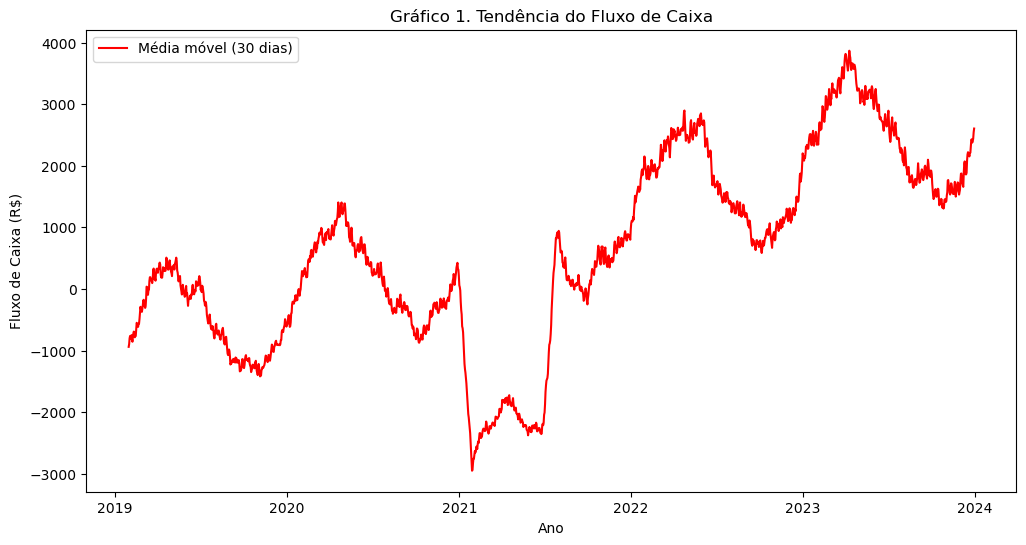

In [ ]:
plt.figure(figsize=(12,6))

# Média móvel para suavizar ruído da série temporal e revelar tendências
df['fluxo_mm30'] = df['fluxo_caixa'].rolling(30).mean()

plt.plot(df['data'], df['fluxo_mm30'], color='red', label='Média móvel (30 dias)')

plt.title('Gráfico 1. Tendência do Fluxo de Caixa')
plt.xlabel('Ano')
plt.ylabel('Fluxo de Caixa (R$)')
plt.legend()

plt.show()


### 5.2 - Sazonalidade

#### 5.2.1. Sazonalidade por mês

In [ ]:
#Média mensal do fluxo de caixa para identificar padrões sazonais

sazonalidade = df.groupby('mes')['fluxo_caixa'].mean()
sazonalidade

mes
1      142.955032
2      661.928323
3     1083.535372
4     1066.015965
5      806.889178
6      574.501717
7      724.852841
8      355.855075
9       90.061438
10     244.494141
11     451.894432
12    1038.814446
Name: fluxo_caixa, dtype: float64

A análise de sazonalidade mensal revela padrão consistente de geração de caixa ao longo do ano. Observa-se crescimento significativo no primeiro trimestre, seguido por desaceleração progressiva até setembro, mês que apresenta o menor fluxo médio. A partir de outubro ocorre recuperação gradual, culminando em novo pico em dezembro. Isso indica que há influência de fatores sazonais na atividade operacional da empresa.

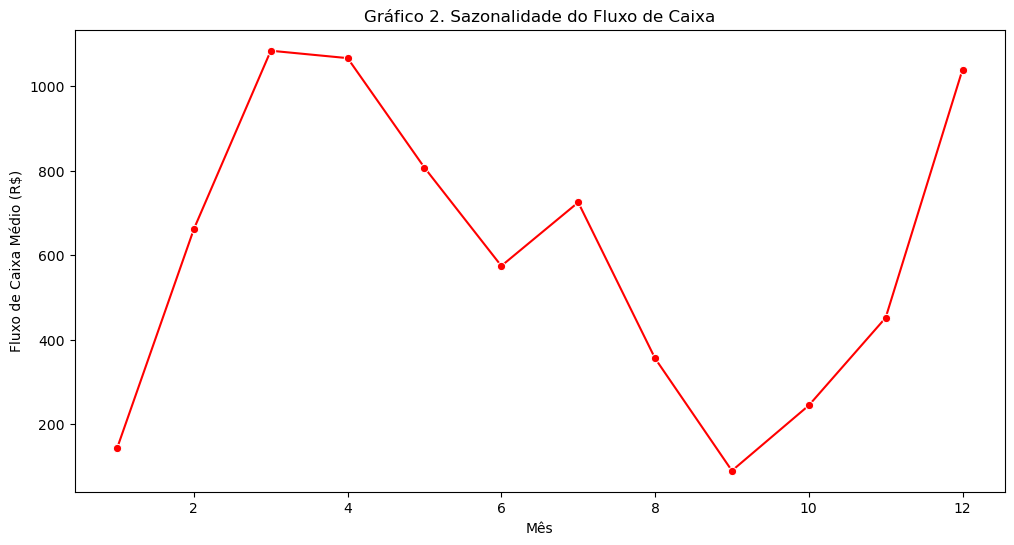

In [ ]:
# Gráfico de sazonalidade

plt.figure(figsize=(12,6))
sns.lineplot(x=sazonalidade.index, y=sazonalidade.values, color='red', marker='o')

plt.title('Gráfico 2. Sazonalidade do Fluxo de Caixa')
plt.xlabel('Mês')
plt.ylabel('Fluxo de Caixa Médio (R$)')

plt.show()

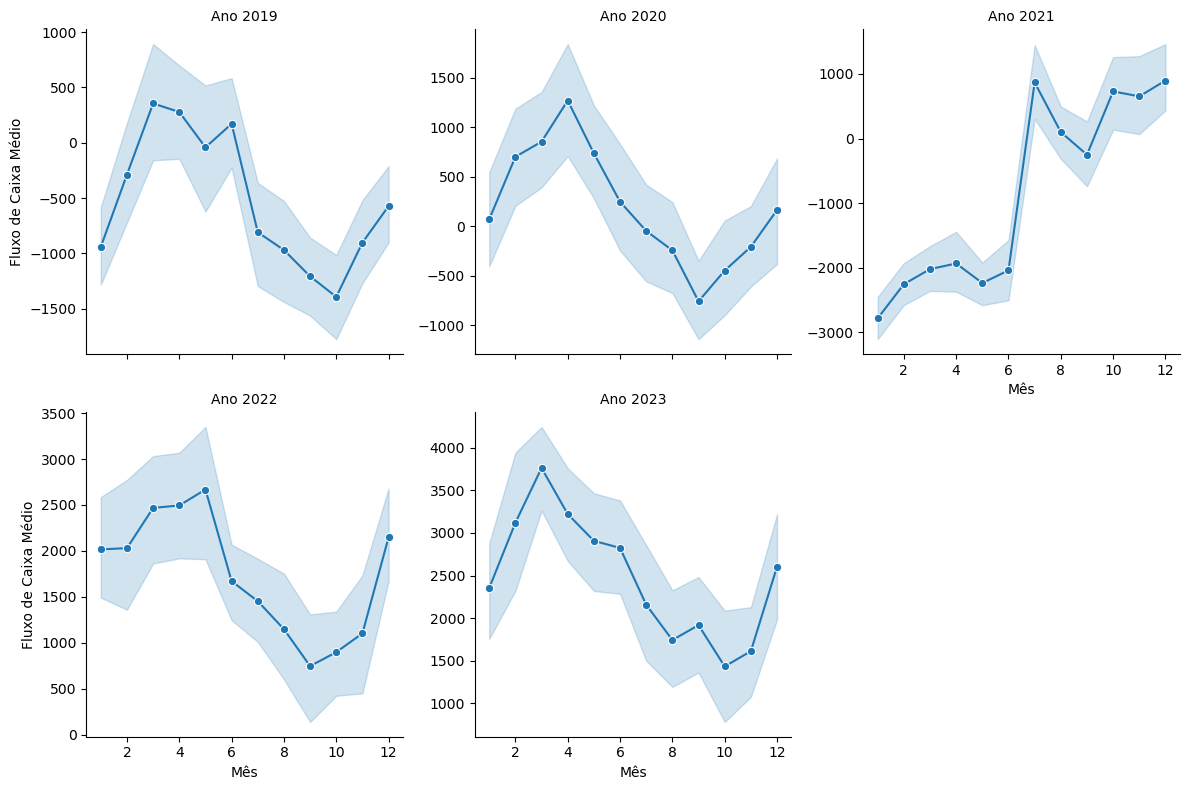

In [ ]:
# Análise de tendências por ano para identificar mudanças ao longo do tempo

g = sns.FacetGrid(
    df,
    col='ano',
    col_wrap=3,
    height=4,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x='mes',
    y='fluxo_caixa',
    estimator='mean',
    marker='o'
)

g.set_axis_labels("Mês", "Fluxo de Caixa Médio")
g.set_titles("Ano {col_name}")

plt.show()

#### 5.2.2. Sazonalidade por dia da semana

In [ ]:
# Análise do fluxo de caixa por dia da semana para identificar padrões semanais

dias = {
0: "Seg",
1: "Ter",
2: "Qua",
3: "Qui",
4: "Sex",
5: "Sab",
6: "Dom"
}

fluxo_semana = df.groupby('dia_semana')['fluxo_caixa'].mean()
fluxo_semana

dia_semana
0    -206.004339
1     -66.849497
2    -267.518109
3    -209.939118
4    1708.141807
5    1624.329324
6    1642.733549
Name: fluxo_caixa, dtype: float64

A análise da sazonalidade semanal revela padrão consistente de geração de caixa concentrada entre sexta-feira e domingo. Em contraste, os dias úteis apresentam fluxo médio negativo, sugerindo predominância de desembolsos operacionais nesse período. Esse comportamento sugere dependência significativa do fluxo de caixa gerado no final da semana para sustentar a liquidez da empresa.

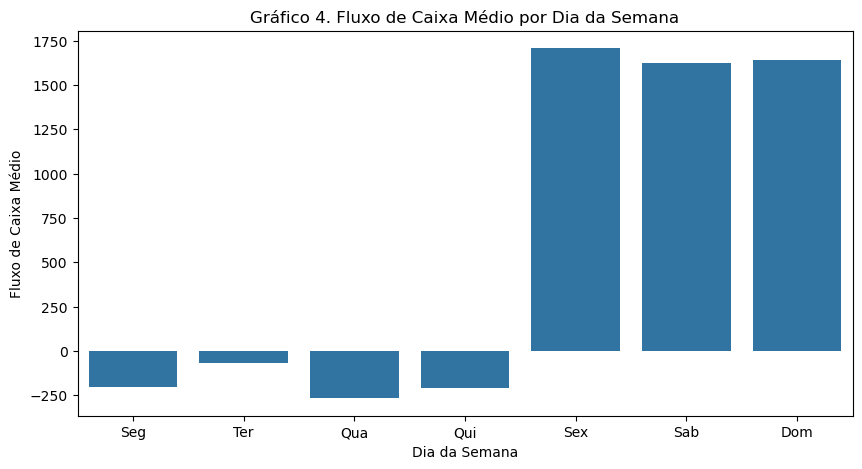

In [ ]:
# Gráfico de fluxo de caixa médio por dia da semana

plt.figure(figsize=(10,5))

sns.barplot(
    x=[dias[d] for d in fluxo_semana.index],
    y=fluxo_semana.values
)

plt.title("Gráfico 4. Fluxo de Caixa Médio por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Fluxo de Caixa Médio")

plt.show()

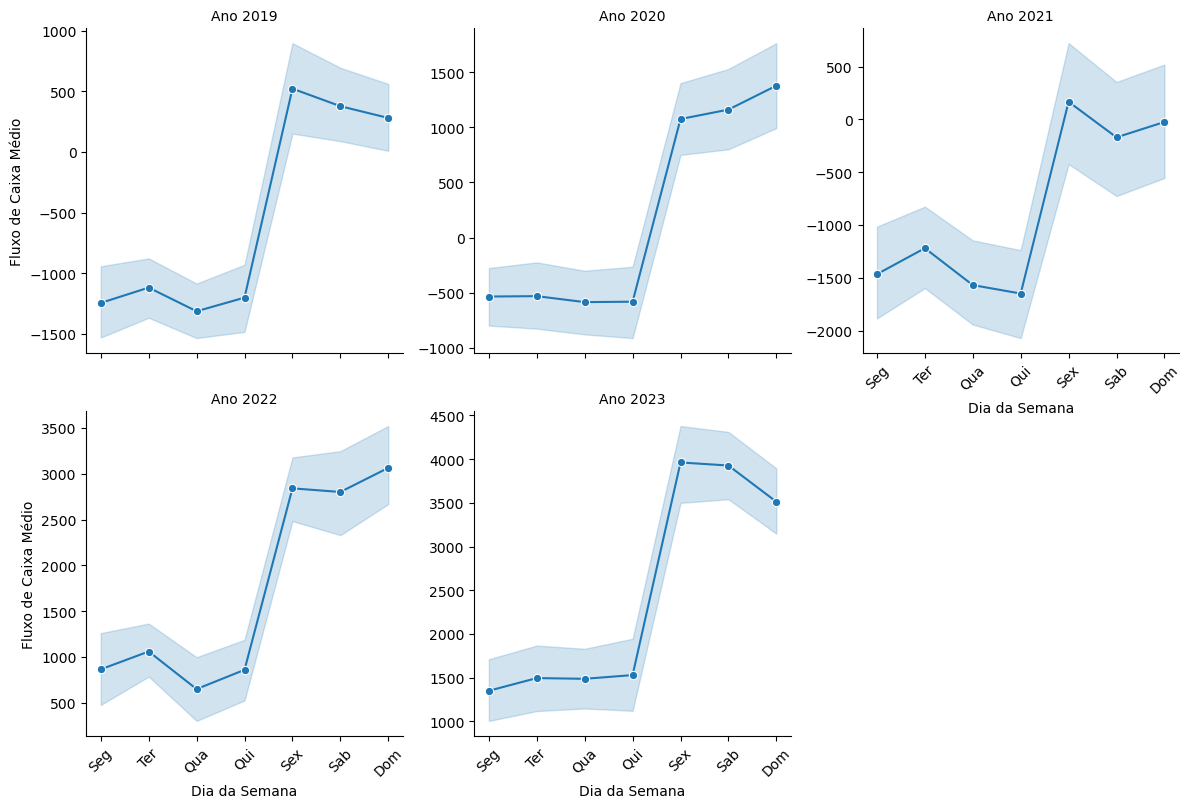

In [ ]:
# Análise detalhada do fluxo de caixa por dia da semana ao longo dos anos para identificar mudanças nos padrões semanais

df['dia_nome'] = df['dia_semana'].map(dias)

ordem_dias = ['Seg','Ter','Qua','Qui','Sex','Sab','Dom']

# transformar em categoria ordenada
df['dia_nome'] = pd.Categorical(
    df['dia_nome'],
    categories=ordem_dias,
    ordered=True
)

g = sns.FacetGrid(
    df,
    col='ano',
    col_wrap=3,
    height=4,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x='dia_nome',
    y='fluxo_caixa',
    estimator='mean',
    marker='o'
)

g.set_axis_labels("Dia da Semana", "Fluxo de Caixa Médio")
g.set_titles("Ano {col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.show()
plt.show()

### 5.3 - Meses críticos

Além disso, nota-se uma maior geração de caixa nos meses de março, abril e dezembro, indicando períodos de maior atividade econômica e maior liquidez da empresa. Já os meses de agosto e setembro apresentam menor geração de caixa, sugerindo possível período sazonal de desaceleração das atividades. Apesar de apresentarem maior geração média de caixa, os meses do primeiro semestre também exibem maior volatilidade, indicando maior variabilidade nas entradas e saídas financeiras. 

A presença de outliers positivos em alguns meses indica ocorrências pontuais de geração extraordinária de caixa. O gráfico mostra, ainda, que vários meses possuem valores mínimos bastante negativos, sugerindo que mesmo meses com maior geração média de caixa, observa-se ocorrência de fluxos negativos em determinados dias, evidenciando risco de liquidez no curto prazo.

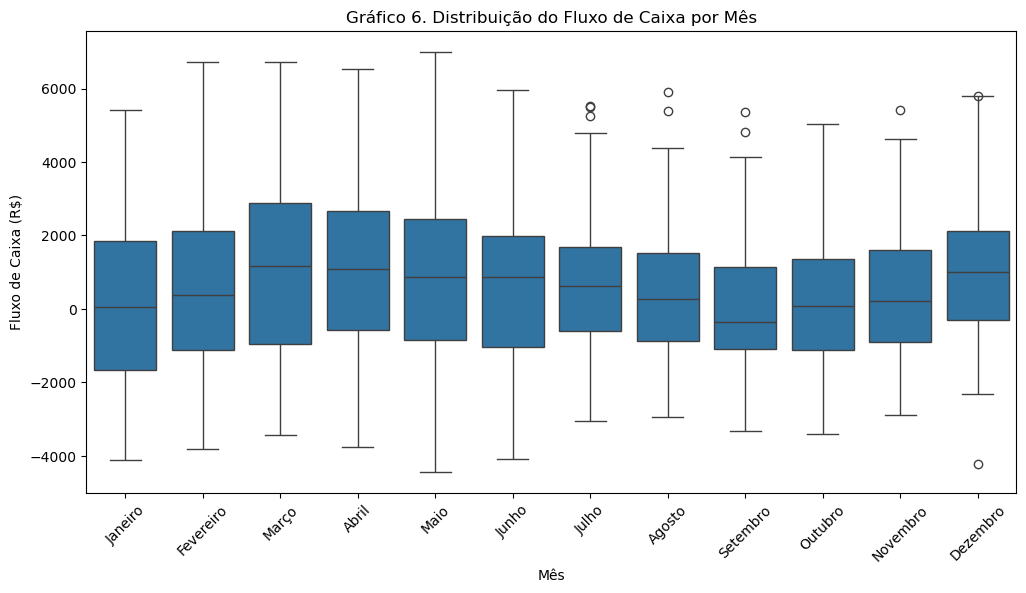

In [ ]:
# Análise da distribuição do fluxo de caixa por mês para identificar variações e outliers

plt.figure(figsize=(12,6))
sns.boxplot(x='mes_nome', y='fluxo_caixa', data=df)

plt.xticks(rotation=45)
plt.title('Gráfico 6. Distribuição do Fluxo de Caixa por Mês')
plt.xlabel("Mês")
plt.ylabel("Fluxo de Caixa (R$)")
plt.show()

### 5.4 - Série temporal

A análise da série temporal da receita bruta, receita recebbida e fluxo de caixa revela que há um crescimento estrutural da receita ao longo da série histórica, sugerindo expansão das operações e aumento do volume de vendas da empresa. A diferença consistente entre receita bruta e receita recebida reflete o impacto da inadimplência sobre a geração de caixa da empresa.

Durante o período de crise no caixa da empresa, observa-se redução significativa na receita e deterioração acentuada do fluxo de caixa. Após o período de crise, nota-se recuperação consistente da receita e melhoria significativa do fluxo de caixa.

O fluxo de caixa apresenta maior volatilidade em comparação às receitas, refletindo a influência de custos operacionais e fatores financeiros adicionais. Portanto, o crescimento da receita é acompanhado por crescimento do fluxo de caixa.

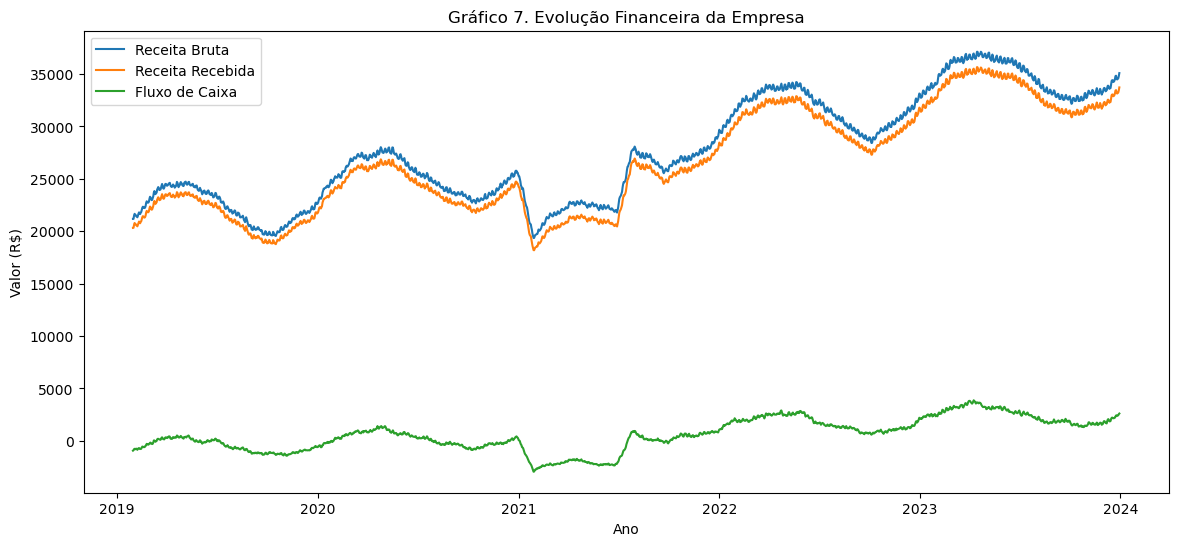

In [ ]:
# Análise da evolução da margem operacional ao longo do tempo para avaliar a rentabilidade da empresa

plt.figure(figsize=(14,6))

# Média móvel para suavizar ruído da série temporal e revelar tendências

df['receita_bruta_mm30'] = df['receita_bruta'].rolling(30).mean()
df['receita_recebida_mm30'] = df['receita_recebida'].rolling(30).mean()
df['fluxo_caixa_mm30'] = df['fluxo_caixa'].rolling(30).mean()

# Gráfico de evolução financeira da empresa ao longo do tempo para identificar tendências e sazonalidades

sns.lineplot(data=df, x='data', y=df['receita_bruta_mm30'], label='Receita Bruta')
sns.lineplot(data=df, x='data', y=df['receita_recebida_mm30'], label='Receita Recebida')
sns.lineplot(data=df, x='data', y=df['fluxo_caixa_mm30'], label='Fluxo de Caixa')

plt.title('Gráfico 7. Evolução Financeira da Empresa')
plt.xlabel('Ano')
plt.ylabel('Valor (R$)')
plt.legend()

plt.show()

### 5.5 - Evolução da inadimplência

Antes do período de crise, a taxa de inadimplência manteve-se estável em torno de 4%, indicando um nível relativamente controlado de risco de crédito. Já durante o período de crise, contudo, observa-se aumento abrupto da inadimplência, indicando deterioração da capacidade de pagamento dos clientes. Após o período de crise, a taxa de inadimplência retorna rapidamente ao patamar histórico — apesar da maior ocilação do período pós-crise — o que indica recuperação da qualidade da carteira de clientes.

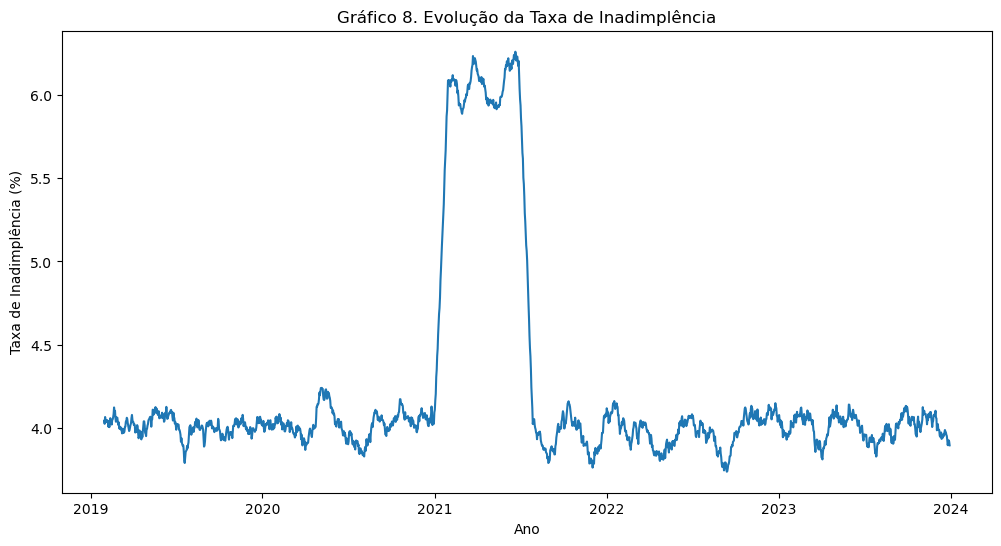

In [ ]:
plt.figure(figsize=(12,6))

# Média móvel para suavizar ruído da série temporal e revelar tendências

df['inadimplencia_mm30'] = df['inadimplencia'].rolling(30).mean()*100

# Gráfico de evolução da taxa de inadimplência ao longo do tempo

sns.lineplot(x='data', y=df['inadimplencia_mm30'], data=df)

plt.title('Gráfico 8. Evolução da Taxa de Inadimplência')
plt.xlabel('Ano')
plt.ylabel('Taxa de Inadimplência (%)')

plt.show()

### 5.6 - Lucro operacional e Margem operacional ao longo da série histórica

O **lucro operacional** pode ser entendido como uma medida de rentabilidade das atividades principais de uma empresa, subtraindo despesas operacionais (vendas, administrativas) do lucro bruto, refletindo, assim, a eficiência na geração de caixa sem considerar juros e impostos.

In [ ]:
#Criação da variável de lucro operacional

df['lucro_operacional'] = (
    df['receita_recebida']
    - df['custo_variavel']
    - df['custo_fixo']
    )

df.head()

,data,receita_bruta,receita_recebida,custo_fixo,custo_variavel,inadimplencia,prazo_medio_recebimento,fluxo_caixa,indicador_crise,dia_semana,mes,ano,mes_nome,fluxo_mm30,dia_nome,receita_bruta_mm30,receita_recebida_mm30,fluxo_caixa_mm30,inadimplencia_mm30,lucro_operacional
0,2019-01-01,19707.817668,18871.899804,8147.574661,10557.933052,0.042416,47.979657,-2314.340169,0,1,1,2019,January,NaN,Ter,NaN,NaN,NaN,NaN,166.392090
1,2019-01-02,18859.843936,18204.071928,8013.214714,9929.049530,0.034771,43.666935,-1916.044437,0,2,1,2019,January,NaN,Qua,NaN,NaN,NaN,NaN,261.807685
2,2019-01-03,20036.682760,19089.870791,7781.119710,9310.435588,0.047254,40.100671,-98.990339,0,3,1,2019,January,NaN,Qui,NaN,NaN,NaN,NaN,1998.315493
3,2019-01-04,25833.686065,24810.920472,7994.650047,13408.517100,0.039590,42.358930,528.399785,0,4,1,2019,January,NaN,Sex,NaN,NaN,NaN,NaN,3407.753324
4,2019-01-05,22871.282748,21951.015005,8364.887146,12453.468495,0.040237,41.448338,-1360.034004,0,5,1,2019,January,NaN,Sab,NaN,NaN,NaN,NaN,1132.659364


Já a **margem operacional** mede o percentual de lucro que uma empresa gera a partir de suas atividades principais, descontando custos e despesas operacionais (como produção, vendas e administração), mas antes de juros e impostos, podendo ser calculada pela razão entre o lucro operacional e a receita líquida.

No dataset utilizado neste projeto, a variável 'receita_recebida', por motivos de semelhança conceitual, foi utilizada como proxy de receita líquida.

In [ ]:
# Cálculo da margem operacional como porcentagem da receita recebida

df['margem_operacional'] = (
    df['lucro_operacional'] / df['receita_recebida']
)*100

O **gráfico 9** evidencia o crescimento estrutural do lucro operacional ao longo do período analisado, indicando expansão das operações da empresa e melhoria na geração de resultados; durante o período de crise, observa-se queda abrupta no lucro operacional, seguido pela recuperação da tendência de crescimento do lucro a partir do segundo semestre de 2021.

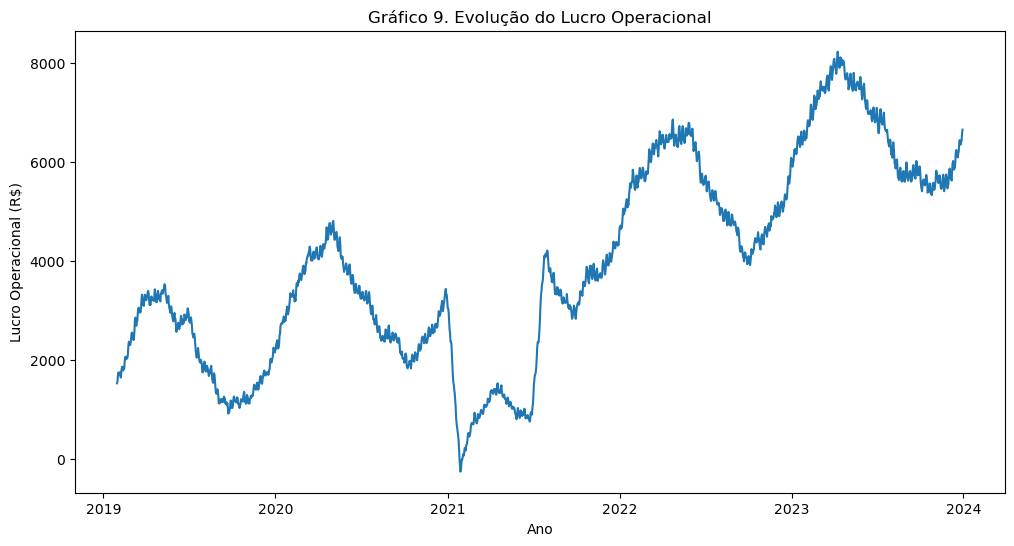

In [ ]:
plt.figure(figsize=(12,6))

# Média móvel para suavizar ruído da série temporal e revelar tendências
df['lucro_operacional_mm30'] = df['lucro_operacional'].rolling(30).mean()

# Gráfico de evolução do lucro operacional ao longo do tempo
sns.lineplot(data=df, x='data', y=df['lucro_operacional_mm30'])

plt.title('Gráfico 9. Evolução do Lucro Operacional')
plt.xlabel('Ano')
plt.ylabel('Lucro Operacional (R$)')

plt.show()

Há, também, aumento consistente na margem operacional ao longo do período, como mostra o **gráfico 10**, indicando melhora da eficiência operacional da empresa, seguido por queda no período de crise e sua consecutiva retomada da tendência de crescimento ao final deste período.

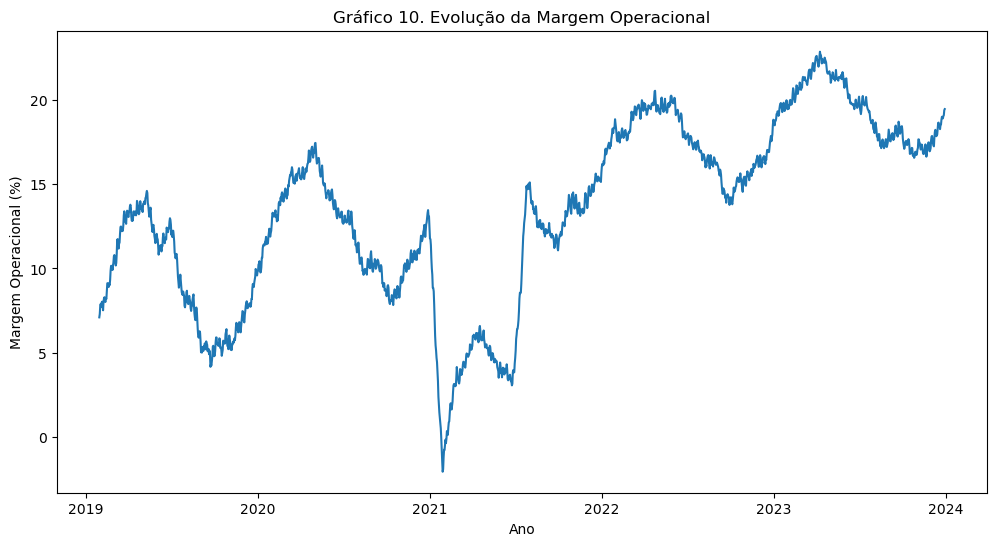

In [ ]:
plt.figure(figsize=(12,6))

# Média móvel para suavizar ruído da série temporal e revelar tendências
df['margem_operacional_mm30'] = df['margem_operacional'].rolling(30).mean()

# Gráfico de evolução da margem operacional ao longo do tempo para avaliar a rentabilidade da empresa
sns.lineplot(data=df, x='data', y=df['margem_operacional_mm30'])

plt.title("Gráfico 10. Evolução da Margem Operacional")
plt.xlabel("Ano")
plt.ylabel("Margem Operacional (%)")

plt.show()

### 5.7 - Drivers do Fluxo de Caixa

Compreendido o cenário do fluxo de caixa ao longo da série histórica analisada, além da análise de outras variáveis, cabe, agora, compreender como se estabelece a relação entre as variáveis financeiras e operacionais e o fluxo de caixa.

A análise de correlação indica que o fluxo de caixa está fortemente associado ao desempenho operacional da empresa, especialmente ao **lucro operacional (0,97), a margem operacional (0,96)** e às variáveis de **receita bruta e receita recebida (0,86)**. Isso sugere que o aumento das receitas e da eficiência operacional tende a se refletir diretamente na geração de caixa.

Além disso, os custos variáveis apresentam correlação positiva relevante (0,72), o que indica que períodos de maior atividade econômica — com maior volume de vendas — tendem a elevar simultaneamente os custos variáveis e o fluxo de caixa, refletindo expansão das operações.

Por outro lado, fatores ligados à gestão de recebíveis mostram impacto negativo sobre o fluxo de caixa. A **inadimplência (-0,40)** e o **prazo médio de recebimento (-0,37)** apresentam correlações negativas moderadas, sugerindo que atrasos ou falhas no pagamento por parte dos clientes reduzem a liquidez da empresa.

Esses resultados indicam que, além de expandir receitas, melhorar o controle da inadimplência e reduzir o prazo de recebimento podem ser estratégias importantes para fortalecer o fluxo de caixa.

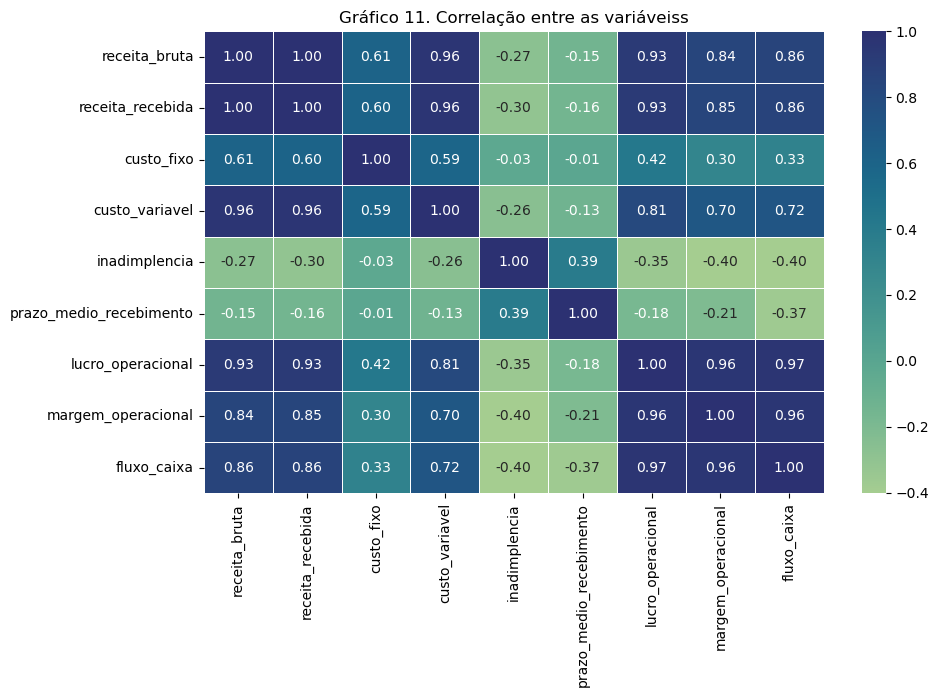

In [ ]:
variaveis_corr_ = [
    'receita_bruta',
    'receita_recebida',
    'custo_fixo',
    'custo_variavel',
    'inadimplencia',
    'prazo_medio_recebimento',
    'lucro_operacional',
    'margem_operacional',
    'fluxo_caixa'
]

corr = df[variaveis_corr_].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='crest',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Gráfico 11. Correlação entre as variáveiss')

plt.show()

### 5.7.1. Impacto da inadimplência no fluxo de caixa

O gráfico abaixo mostra a relação entre risco e liquidez. A partir da análise do **gráfico 11**, como dito anteriormente, nota-se uma correlação negativa entre inadimplência e fluxo de caixa (-0.40).

Como se pode ver logo abaixo, o teste estatístico apresentou p-value < 0.001, indicando que a correlação observada é estatisticamente significativa.

Isso sugere que aumentos na taxa de inadimplência estão associados à redução do fluxo de caixa da empresa. O **gráfico 12** demonstra essa relação.

In [ ]:
from scipy import stats

# Análise de correlação entre inadimplência e fluxo de caixa para avaliar o impacto da inadimplência na liquidez da empresa

pearson_coef, p_value = stats.pearsonr(df['inadimplencia'], df['fluxo_caixa'])
print("O coeficiente de correlação de Pearson é", pearson_coef, " com um valor-P de P =", p_value)

O coeficiente de correlação de Pearson é -0.40051602950688137  com um valor-P de P = 2.841048645178944e-71


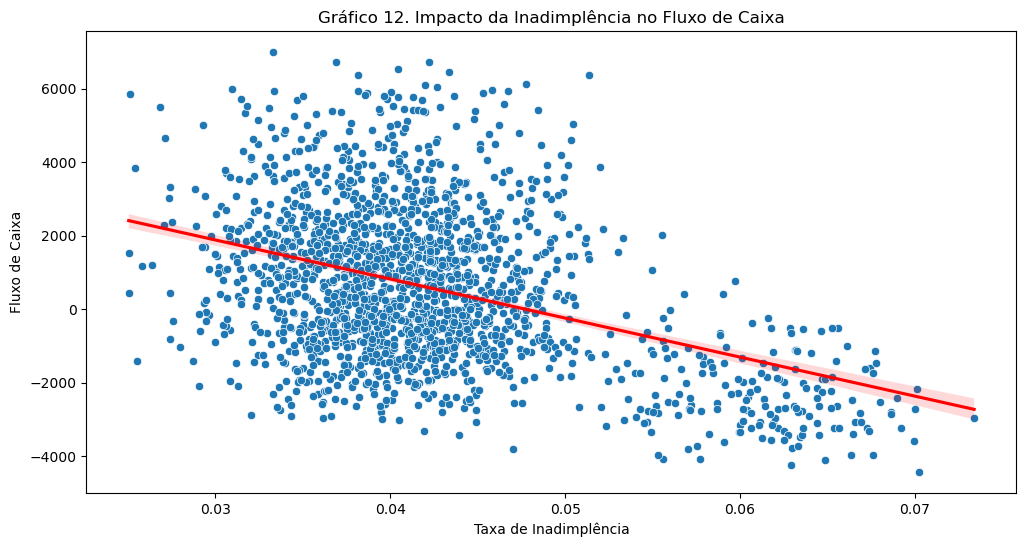

In [ ]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='inadimplencia',
    y='fluxo_caixa',
)

sns.regplot(
    data=df,
    x='inadimplencia',
    y='fluxo_caixa',
    scatter=False,
    color='red'
)

plt.title("Gráfico 12. Impacto da Inadimplência no Fluxo de Caixa")

plt.xlabel("Taxa de Inadimplência")
plt.ylabel("Fluxo de Caixa")

plt.show()

### 5.7.2. Impacto do prazo médio de recebimento no fluxo de caixa

O gráfico abaixo sugere uma relação negativa entre o prazo médio de recebimento e o fluxo de caixa da empresa: quanto maior o prazo médio de recebimento, menor tende a ser o fluxo de caixa. A ampliação do prazo de recebimento compromete a liquidez da empresa, pois posterga a entrada de recursos financeiros.

Apesar da tendência negativa observada, a elevada dispersão indica que outros fatores também influenciam significativamente o fluxo de caixa. Isso é coerente com o valor do coeficiente de correlação (-0,37) e estatisticamente significativo (p-valor < 0,01).

De forma aproximada, o gráfico indica que aumentar o prazo em 30 dias de uma venda pode reduzir o fluxo de caixa em cerca de R$3.000.

In [ ]:
pearson_coef, p_value = stats.pearsonr(df['prazo_medio_recebimento'], df['fluxo_caixa'] )
pearson_coef, p_value

(np.float64(-0.3704202232097019), np.float64(1.8979561443005972e-60))

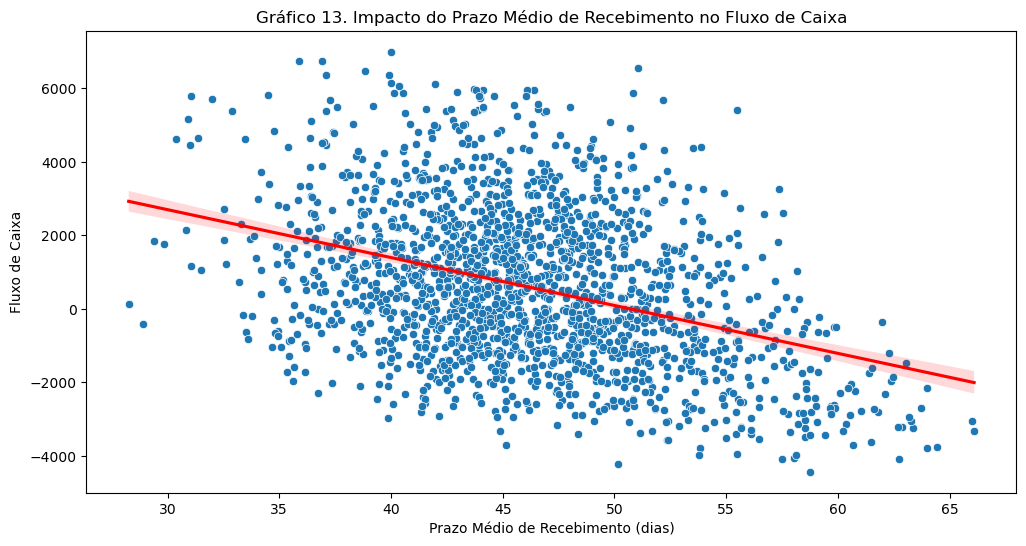

In [ ]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='prazo_medio_recebimento',
    y='fluxo_caixa',
)

sns.regplot(
    data=df,
    x='prazo_medio_recebimento',
    y='fluxo_caixa',
    scatter=False,
    color='red'
)

plt.title("Gráfico 13. Impacto do Prazo Médio de Recebimento no Fluxo de Caixa")

plt.xlabel("Prazo Médio de Recebimento (dias)")
plt.ylabel("Fluxo de Caixa")

plt.show()

### 5.7.3. Impacto dos custos fixo e variável no fluxo de caixa

Os resultados abaixo indicam diferenças importantes na forma como custos fixos e custos variáveis se relacionam com o fluxo de caixa. A correlação entre custo fixo e fluxo de caixa (0,32) é positiva, porém relativamente fraca, o que sugere que aumentos nos custos fixos não estão fortemente associados a aumentos ou reduções no fluxo de caixa.

Em outros termos, isso indica que os custos fixos tendem a se manter relativamente estáveis e não variam diretamente com o desempenho financeiro de curto prazo da empresa. Ainda que o p-value seja extremamente baixo, indicando significância estatística, a magnitude da correlação sugere que o custo fixo não é um fator determinante relevante — ou apenas não consegue explicar sozinho — para explicar variações no fluxo de caixa.

In [ ]:
pearson_coef, p_value = stats.pearsonr(df['custo_fixo'], df['fluxo_caixa'] )
pearson_coef, p_value

(np.float64(0.32839695220068843), np.float64(3.799122225023422e-47))

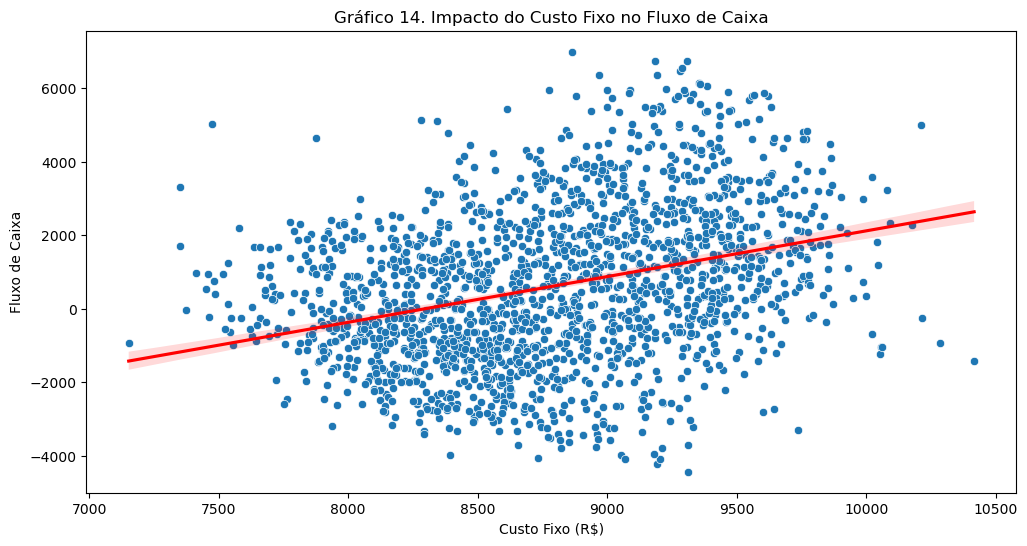

In [ ]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='custo_fixo',
    y='fluxo_caixa',
)

sns.regplot(
    data=df,
    x='custo_fixo',
    y='fluxo_caixa',
    scatter=False,
    color='red'
)

plt.title("Gráfico 14. Impacto do Custo Fixo no Fluxo de Caixa")

plt.xlabel("Custo Fixo (R$)")
plt.ylabel("Fluxo de Caixa")

plt.show()

In [ ]:
pearson_coef, p_value = stats.pearsonr(df['custo_variavel'], df['fluxo_caixa'] )
pearson_coef, p_value

(np.float64(0.7173348434077869), np.float64(2.0918838089201083e-288))

Por outro lado, o custo variável apresenta uma correlação positiva forte com o fluxo de caixa (0,71), indicando que períodos de maior custo variável tendem a coincidir com períodos de maior geração de caixa. Isso sugere que os custos variáveis estão fortemente ligados ao nível de atividade da empresa, como volume de vendas ou produção.

Em termos gerenciais, esse resultado indica que o crescimento das operações aumenta simultaneamente os custos variáveis e o fluxo de caixa, refletindo maior movimentação econômica.

Assim, embora custos variáveis representem saídas de recursos, eles parecem estar associados a operações que geram receitas suficientes para elevar o fluxo de caixa, evidenciando que o desempenho financeiro está mais relacionado ao nível de atividade do negócio do que à estrutura de custos fixos.

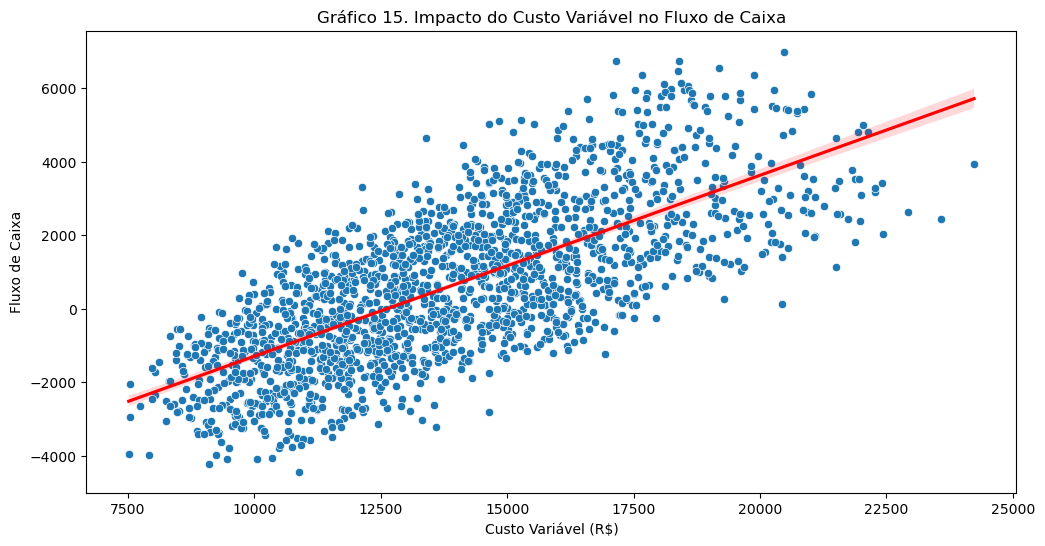

In [ ]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='custo_variavel',
    y='fluxo_caixa',
)

sns.regplot(
    data=df,
    x='custo_variavel',
    y='fluxo_caixa',
    scatter=False,
    color='red'
)

plt.title("Gráfico 15. Impacto do Custo Variável no Fluxo de Caixa")

plt.xlabel("Custo Variável (R$)")
plt.ylabel("Fluxo de Caixa")

plt.show()

## 6. Principais Insights e Implicações para o Negócio

**1. Um aumento de 20 dias no prazo médio de recebimento está associado, aproximadamente, a uma redução de 93.3% no fluxo de caixa operacional.**

A análise identificou uma relação negativa entre o prazo médio de recebimento e o fluxo de caixa. Quanto maior o tempo que a empresa leva para receber pagamentos de clientes, menor tende a ser a disponibilidade de caixa.

Esse resultado indica que políticas de crédito mais flexíveis, que aumentam o prazo de pagamento concedido aos clientes, podem gerar pressões sobre a liquidez da empresa.

**2. Períodos com maior taxa de inadimplência apresentam deterioração do fluxo de caixa, indicando que a recuperação de crédito é um fator relevante para a saúde financeira da empresa.**

Os resultados mostram uma correlação negativa entre inadimplência e fluxo de caixa, indicando que períodos de maior atraso ou não pagamento por parte dos clientes tendem a coincidir com menor disponibilidade de recursos financeiros. Esse resultado reforça a importância da gestão do risco de crédito.

**3. O fluxo de caixa acompanha o nível de atividade da empresa, com períodos de maior volume de vendas apresentando geração de caixa proporcionalmente maior.**

A análise revelou uma forte correlação positiva entre custos variáveis e fluxo de caixa. Esse resultado sugere que períodos com maiores custos variáveis também apresentam maior geração de caixa. Isso ocorre porque custos variáveis estão diretamente associados ao nível de atividade operacional da empresa, como produção ou vendas.

**4. Custos fixos apresentam impacto relativamente estável no fluxo de caixa de curto prazo, indicando que a volatilidade do caixa está mais associada a fatores operacionais e variáveis.**

A correlação entre custos fixos e fluxo de caixa foi relativamente baixa. Isso sugere que variações no fluxo de caixa da empresa estão menos associadas à estrutura de custos fixos e mais relacionadas a fatores operacionais.

Custos fixos tendem a permanecer relativamente estáveis ao longo do tempo e não respondem diretamente às flutuações de curto prazo na atividade econômica da empresa.

**5. O fluxo de caixa é influenciado principalmente por fatores operacionais**

De forma geral, os resultados indicam que as variações no fluxo de caixa da empresa estão mais associadas a fatores operacionais, como: **(1) nível de atividade econômica**; **(2) prazos de recebimento** e **(3) comportamento de pagamento dos clientes** do que a mudanças estruturais nos custos da empresa.

## 7. Recomendações Gerenciais


**Caso 1. Prazo médio de recebimento**

A empreza pode avaliar políticas para reduzir o prazo médio de recebimento, como:

- oferecer descontos para pagamentos antecipados;

- fortalecer processos de cobrança e

- revisar limites de crédito concedidos a clientes.

**Caso 2. Inadimplência**

A empresa pode implementar medidas como:

- análise de crédito mais rigorosa, como monitoramento contínuo de clientes com histórico de atraso e

- revisão das políticas de cobrança.

**Caso 3. Custos variáveis**

A empresa deve interpretar aumentos de custos variáveis em conjunto com indicadores de receita e volume de vendas, pois eles podem representar expansão das operações, que é o que mais influencia o fluxo de caixa.

**Caso 4. Custos fixos**

A gestão do fluxo de caixa deve focar principalmente em fatores operacionais e de capital de giro, como:

- gestão de recebíveis

- controle da inadimplência

- planejamento de entradas e saídas de caixa.

## 8. Conclusão

Este projeto teve como objetivo analisar os principais fatores associados às variações no fluxo de caixa de uma empresa por meio de técnicas de análise exploratória de dados. 

Os resultados indicaram que fatores operacionais relacionados ao capital de giro, como prazo médio de recebimento e inadimplência, apresentam relação significativa com a disponibilidade de caixa da empresa. Além disso, observou-se que os custos variáveis estão fortemente associados ao nível de atividade econômica, enquanto os custos fixos possuem relação mais limitada com as variações de curto prazo do fluxo de caixa. Esses resultados podem contribuir para o aprimoramento das políticas de crédito, cobrança e planejamento financeiro.

Os próximos passos deste projeto envolverão a construção de modelos preditivos para estimar o fluxo de caixa futuro e avaliar com maior precisão o impacto de diferentes variáveis financeiras sobre a liquidez da empresa.